---
jupyter: python3
format:
  html:
    code-fold: true
    code-tools: true
bibliography: ../../references.bib
author:
  - name: XXXX
    id: dw
    orcid: XXXX
    email: XXXX
    corresponding: true
    degrees: PhD
    affiliation: 
      - name: The Alan Turing Institute
        city: London
        country: United Kingdom
        url: www.turing.ac.uk

---

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
from utils import country_year_checker, read_icem, icem_merge

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Set census year and country

In [2]:
country = "GB"
year = 1901

country_year_checker(country, year, )

## Read I-CeM

In [3]:
census_csv_params = {
	"sep": "\t",
	"encoding": "latin-1",
	"quoting": 3,
	"na_values": [".", " "],
	"usecols": ["RecID",  "Occode", "ParID", "Servts", ],
	# "usecols": ["RecID", "RC", "Address", ],
	# "nrows":10000
}

ew_census = pd.read_csv("../../icem/EW01outputfile_corrected.txt", 
                        **census_csv_params)

ew_census["Country"] = "EW"


scot_census = pd.read_csv("../../icem/scot01outputfile.txt", 
                        **census_csv_params)

scot_census["Country"] = "scot"

icem = pd.concat([ew_census, scot_census]).reset_index(drop=True)
icem

,RecID,ParID,Occode,Servts,Country
0,1,1,409.0,0.0,EW
1,2,1,NaN,0.0,EW
2,3,1,440.0,0.0,EW
3,4,1,653.0,0.0,EW
4,5,1,766.0,0.0,EW
...,...,...,...,...,...
36931021,4438427,100882,787.0,2.0,scot
36931022,4438428,100882,999.0,2.0,scot
36931023,4438429,100882,659.0,0.0,scot
36931024,4438430,100882,101.0,0.0,scot


## Add additional variables

In [4]:
#from icem

census_csv_params = {
	"sep": "\t",
	"encoding": "latin-1",
	"quoting": 3,
	"na_values": [".", " "],
	"usecols": ["RecID",  "Rela", "Age" ],
	# "usecols": ["RecID", "RC", "Address", ],
	# "nrows":10000
}

ew_census = pd.read_csv("../../icem/EW01outputfile.txt", 
                        **census_csv_params)

ew_census["Country"] = "EW"


scot_census = pd.read_csv("../../icem/scot01outputfile.txt", 
                        **census_csv_params)

scot_census["Country"] = "scot"

icem_addon = pd.concat([ew_census, scot_census]).reset_index(drop=True)
icem_addon


,RecID,Age,Rela,Country
0,1,63.0,11,EW
1,2,54.0,22,EW
2,3,30.0,31,EW
3,4,28.0,31,EW
4,5,26.0,31,EW
...,...,...,...,...
36931731,4438427,5.0,31,scot
36931732,4438428,1.0,32,scot
36931733,4438429,70.0,2000,scot
36931734,4438430,19.0,6000,scot


In [5]:
icem2 = pd.merge(left = icem,
                 right = icem_addon,
                 on = ["RecID", "Country"],
                 how = "left")

icem2

,RecID,ParID,Occode,Servts,Country,Age,Rela
0,1,1,409.0,0.0,EW,63.0,11
1,2,1,NaN,0.0,EW,54.0,22
2,3,1,440.0,0.0,EW,30.0,31
3,4,1,653.0,0.0,EW,28.0,31
4,5,1,766.0,0.0,EW,26.0,31
...,...,...,...,...,...,...,...
36931021,4438427,100882,787.0,2.0,scot,5.0,31
36931022,4438428,100882,999.0,2.0,scot,1.0,32
36931023,4438429,100882,659.0,0.0,scot,70.0,2000
36931024,4438430,100882,101.0,0.0,scot,19.0,6000


### Custom Occupational Codes

In [6]:
list_of_cols = ['Rail Dependence','OCCODE']
custom_occ_codes = pd.read_excel("../data/custom_occs/custom_occ_code.xlsx",sheet_name='MAIN OCC SHEET',usecols=list_of_cols)
custom_occ_codes = custom_occ_codes.dropna()
# display(custom_occ_codes)
custom_occ_codes


custom_occ_codes = dict(zip(custom_occ_codes['OCCODE'],custom_occ_codes['Rail Dependence']))
icem2['custom_occ'] = icem2['Occode'].map(custom_occ_codes).fillna("other")
icem2.head()

,RecID,ParID,Occode,Servts,Country,Age,Rela,custom_occ
0,1,1,409.0,0.0,EW,63.0,11,other
1,2,1,NaN,0.0,EW,54.0,22,other
2,3,1,440.0,0.0,EW,30.0,31,other
3,4,1,653.0,0.0,EW,28.0,31,other
4,5,1,766.0,0.0,EW,26.0,31,other


### Urban class

In [7]:
def add_urban_class(census, country, year, ):

    list_of_cols_ew = ['ParID','Urban_Class', ]
    urban_classification_ew = pd.read_excel("../data/urbanclass/England_Wales_Urban_Classification_1851_1911.xlsx",sheet_name=f"{year}",usecols=list_of_cols_ew)
    urban_classification_ew["Urban_Class_binary"] = np.where(urban_classification_ew["Urban_Class"] == 2, 1, np.where(urban_classification_ew["Urban_Class"] == 3, 4, urban_classification_ew["Urban_Class"]))

    list_of_cols_scot = ['ParID','Burgh', ]
    urban_classification_scot = pd.read_excel("../data/urbanclass/Scotland_Burghs_1851_1901.xlsx",sheet_name=f"{year}",usecols=list_of_cols_scot)
    urban_classification_scot["Urban_Class"] = 1
    urban_classification_scot = urban_classification_scot.drop("Burgh", axis = 1)

    urban_classification_ew_dict = dict(zip(urban_classification_ew['ParID'],urban_classification_ew['Urban_Class']))
    urban_classification_ew_binary_dict = dict(zip(urban_classification_ew['ParID'],urban_classification_ew['Urban_Class_binary']))
    urban_classification_scot_dict = dict(zip(urban_classification_scot['ParID'],urban_classification_scot['Urban_Class']))

    urban_classification_gb_dict = {}
    urban_classification_gb_dict.update(urban_classification_ew_binary_dict)
    urban_classification_gb_dict.update(urban_classification_scot_dict)

    if country == "EW":
        census['urban_class'] = census['ParID'].map(urban_classification_ew_binary_dict)
    elif country == "SCOT":
        census['urban_class'] = census['ParID'].map(urban_classification_scot_dict)
        census['urban_class'] = census['urban_class'].fillna(4)

    elif country == "GB":
        census['urban_class'] = census['ParID'].map(urban_classification_gb_dict)
        census['urban_class'] = census['urban_class'].fillna(4)

    return census


icem2 = add_urban_class(icem2, country, year, )

icem2

,RecID,ParID,Occode,Servts,Country,Age,Rela,custom_occ,urban_class
0,1,1,409.0,0.0,EW,63.0,11,other,1.0
1,2,1,NaN,0.0,EW,54.0,22,other,1.0
2,3,1,440.0,0.0,EW,30.0,31,other,1.0
3,4,1,653.0,0.0,EW,28.0,31,other,1.0
4,5,1,766.0,0.0,EW,26.0,31,other,1.0
...,...,...,...,...,...,...,...,...,...
36931021,4438427,100882,787.0,2.0,scot,5.0,31,other,4.0
36931022,4438428,100882,999.0,2.0,scot,1.0,32,other,4.0
36931023,4438429,100882,659.0,0.0,scot,70.0,2000,other,4.0
36931024,4438430,100882,101.0,0.0,scot,19.0,6000,other,4.0


In [8]:
icem2.groupby(["Country", "urban_class"]).size().unstack()

urban_class,1.0,4.0
Country,,
EW,24480229,8012379
scot,2508208,1930210


### Add Infant Mortality

In [6]:
inf_mort = pd.read_csv("../data/icem_extra_vars/inf_mortality.csv", sep = ",", usecols = ["ParID", "InfMort"])
inf_mort

,ParID,InfMort
0,1,175.79
1,2,174.92
2,3,177.23
3,4,171.01
4,5,108.69
...,...,...
15258,15259,114.58
15259,15260,114.58
15260,15261,122.01
15261,15262,122.01


In [7]:
icem2 = pd.merge(left = icem, right = inf_mort, left_on = "ParID", right_on="ParID", how = "left")
icem2

,RecID,ParID,NoOfRoomsCode,Size,Age,Rela,Occode,Servts,custom_occ,urban_class,InfMort
0,1,1,NaN,7,63.0,11,409.0,0.0,other,1.0,175.79
1,2,1,NaN,7,54.0,22,NaN,0.0,other,1.0,175.79
2,3,1,NaN,7,30.0,31,440.0,0.0,other,1.0,175.79
3,4,1,NaN,7,28.0,31,653.0,0.0,other,1.0,175.79
4,5,1,NaN,7,26.0,31,766.0,0.0,other,1.0,175.79
...,...,...,...,...,...,...,...,...,...,...,...
32493313,32493314,92000,NaN,80,35.0,5900,24.0,NaN,other,NaN,NaN
32493314,32493315,92000,NaN,80,20.0,5900,24.0,NaN,other,NaN,NaN
32493315,32493316,92000,NaN,80,25.0,5900,24.0,NaN,other,NaN,NaN
32493316,32493317,92000,NaN,80,20.0,5900,24.0,NaN,other,NaN,NaN


In [8]:
icem = icem2

## Read street_rail_stations dataset, merging additional variables

In [8]:
csv_params = {
	"sep": "\t",
	"usecols": ["RecID", "distance_comb", "rail_density_100m_comb", "street_uid_comb"],
	# "nrows":1000
}

def read_beyondthetracks(file_path, csv_params, country,  ):
	if country == "GB" and "Country" not in csv_params["usecols"]:
		csv_params["usecols"].append("Country")
	else:
		"do nothing"
	beyondthetracks = pd.read_csv(file_path, **csv_params, )
	
	return beyondthetracks
	
beyondthetracks = read_beyondthetracks(f"../data/outputs/analysis/{country}_{year}_analysis.tsv", csv_params, country, )

beyondthetracks = beyondthetracks[beyondthetracks["street_uid_comb"].isna() == False].copy()
beyondthetracks["rail_density_100m_comb"] = beyondthetracks["rail_density_100m_comb"].fillna(0)
beyondthetracks

,RecID,Country,street_uid_comb,distance_comb,rail_density_100m_comb
0,1,EW,93.0,55.944810,0.375975
1,2,EW,93.0,55.944810,0.375975
2,3,EW,93.0,55.944810,0.375975
3,4,EW,93.0,55.944810,0.375975
4,5,EW,93.0,55.944810,0.375975
...,...,...,...,...,...
36931021,4438427,scot,230197.0,2291.247668,0.000000
36931022,4438428,scot,230197.0,2291.247668,0.000000
36931023,4438429,scot,230197.0,2291.247668,0.000000
36931024,4438430,scot,230197.0,2291.247668,0.000000


In [9]:
beyondthetracks2 = icem_merge(beyondthetracks, icem2, country, "inner", (None, None))
beyondthetracks2

,RecID,Country,street_uid_comb,distance_comb,rail_density_100m_comb,ParID,Occode,Servts,Age,Rela,custom_occ,urban_class
0,1,EW,93.0,55.944810,0.375975,1,409.0,0.0,63.0,11,other,1.0
1,2,EW,93.0,55.944810,0.375975,1,NaN,0.0,54.0,22,other,1.0
2,3,EW,93.0,55.944810,0.375975,1,440.0,0.0,30.0,31,other,1.0
3,4,EW,93.0,55.944810,0.375975,1,653.0,0.0,28.0,31,other,1.0
4,5,EW,93.0,55.944810,0.375975,1,766.0,0.0,26.0,31,other,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
26714985,4438427,scot,230197.0,2291.247668,0.000000,100882,787.0,2.0,5.0,31,other,4.0
26714986,4438428,scot,230197.0,2291.247668,0.000000,100882,999.0,2.0,1.0,32,other,4.0
26714987,4438429,scot,230197.0,2291.247668,0.000000,100882,659.0,0.0,70.0,2000,other,4.0
26714988,4438430,scot,230197.0,2291.247668,0.000000,100882,101.0,0.0,19.0,6000,other,4.0


In [14]:
beyondthetracks2

,RecID,Country,street_uid_comb,distance_comb,rail_density_100m_comb,ParID,Occode,Servts,Age,Rela,custom_occ,urban_class,distance_comb_cut,rail_density_100m_comb_bin
0,1,EW,93.0,55.944810,0.375975,1,409.0,0.0,63.0,11,other,1.0,Under 250m,20-40%
1,2,EW,93.0,55.944810,0.375975,1,NaN,0.0,54.0,22,other,1.0,Under 250m,20-40%
2,3,EW,93.0,55.944810,0.375975,1,440.0,0.0,30.0,31,other,1.0,Under 250m,20-40%
3,4,EW,93.0,55.944810,0.375975,1,653.0,0.0,28.0,31,other,1.0,Under 250m,20-40%
4,5,EW,93.0,55.944810,0.375975,1,766.0,0.0,26.0,31,other,1.0,Under 250m,20-40%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26714985,4438427,scot,230197.0,2291.247668,0.000000,100882,787.0,2.0,5.0,31,other,4.0,2250-2500m,Zero
26714986,4438428,scot,230197.0,2291.247668,0.000000,100882,999.0,2.0,1.0,32,other,4.0,2250-2500m,Zero
26714987,4438429,scot,230197.0,2291.247668,0.000000,100882,659.0,0.0,70.0,2000,other,4.0,2250-2500m,Zero
26714988,4438430,scot,230197.0,2291.247668,0.000000,100882,101.0,0.0,19.0,6000,other,4.0,2250-2500m,Zero


## Create bins of station distances

In [10]:
min = 0
max = 3000
step = 250
extra = [3000,np.inf]
# extra = [250, np.inf]

dist_labels = ['Under 250m','250-500m','500-750m','750-1000m','1000-1250m','1250-1500m','1500-1750m','1750-2000m','2000-2250m','2250-2500m','2500-2750m','2750-3000m','Over 3km']
# dist_labels = ['Under 50m', '50-100m', '100-150m', '150-200m', '200-250m', 'Over 250m']
dist2station_field = "distance_comb"
dist2station_field_binned = "distance_comb_cut"


distance_bins = list(range(min,max,step))
distance_bins.extend(extra)

beyondthetracks2[dist2station_field_binned] = pd.cut(beyondthetracks2[dist2station_field],bins=distance_bins,labels=dist_labels)
beyondthetracks2.head()

,RecID,Country,street_uid_comb,distance_comb,rail_density_100m_comb,ParID,Occode,Servts,Age,Rela,custom_occ,urban_class,distance_comb_cut
0,1,EW,93.0,55.94481,0.375975,1,409.0,0.0,63.0,11,other,1.0,Under 250m
1,2,EW,93.0,55.94481,0.375975,1,NaN,0.0,54.0,22,other,1.0,Under 250m
2,3,EW,93.0,55.94481,0.375975,1,440.0,0.0,30.0,31,other,1.0,Under 250m
3,4,EW,93.0,55.94481,0.375975,1,653.0,0.0,28.0,31,other,1.0,Under 250m
4,5,EW,93.0,55.94481,0.375975,1,766.0,0.0,26.0,31,other,1.0,Under 250m


## Create bins of railspace distances

In [11]:
rail_bins = [-0.1,0,0.2,0.4,0.6,0.8,1]
# rail_labels = ['< 0.2','0.2-0.4','0.4-0.6','0.6-0.8','0.8-1']
rail_labels = ['Zero','< 20%','20-40%','40-60%','60-80%','> 80%']


for dist in [100 ]:
    beyondthetracks2[f'rail_density_{dist}m_comb_bin'] =  pd.cut(beyondthetracks2[f'rail_density_{dist}m_comb'],bins=rail_bins,labels=rail_labels)


beyondthetracks2.head()

,RecID,Country,street_uid_comb,distance_comb,rail_density_100m_comb,ParID,Occode,Servts,Age,Rela,custom_occ,urban_class,distance_comb_cut,rail_density_100m_comb_bin
0,1,EW,93.0,55.94481,0.375975,1,409.0,0.0,63.0,11,other,1.0,Under 250m,20-40%
1,2,EW,93.0,55.94481,0.375975,1,NaN,0.0,54.0,22,other,1.0,Under 250m,20-40%
2,3,EW,93.0,55.94481,0.375975,1,440.0,0.0,30.0,31,other,1.0,Under 250m,20-40%
3,4,EW,93.0,55.94481,0.375975,1,653.0,0.0,28.0,31,other,1.0,Under 250m,20-40%
4,5,EW,93.0,55.94481,0.375975,1,766.0,0.0,26.0,31,other,1.0,Under 250m,20-40%


In [15]:
beyondthetracks2[beyondthetracks2["street_uid_comb"].str.contains("gb1900")]

AttributeError: Can only use .str accessor with string values!

In [ ]:
streets_only = beyondthetracks2.drop_duplicates(subset=["Country", "street_uid_comb"])

In [13]:
beyondthetracks2["typology"] = np.where(((beyondthetracks2["distance_comb"] < 500) & (beyondthetracks2["rail_density_100m_comb"] < 0.2)),"near_light",
                                np.where(((beyondthetracks2["distance_comb"] > 1500) & (beyondthetracks2["rail_density_100m_comb"] >= 0.6)), "far_dense",
                                        np.where(((beyondthetracks2["distance_comb"] < 500) & (beyondthetracks2["rail_density_100m_comb"] >= 0.6)), "near_dense",
                                        np.where(((beyondthetracks2["distance_comb"] > 1500) & (beyondthetracks2["rail_density_100m_comb"] < 0.2)), "far_light","other"))))

In [ ]:
beyondthetracks["typology"] = np.where(((beyondthetracks["distance_comb"] < 500) & (beyondthetracks["rail_density_100m_comb"] < 20)),"highamenity",
                                np.where(((beyondthetracks["distance_comb"] > 1500) & (beyondthetracks["rail_density_100m_comb"] >= 60)), "lowamenity","dasdf"))

In [14]:
beyondthetracks2.groupby("typology").size()

typology
far_dense       101139
far_light      5045845
near_dense      447560
near_light     7391973
other         13728473
dtype: int64

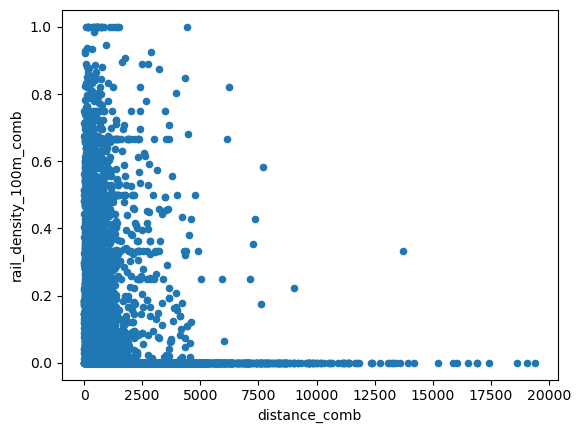

In [17]:
typology_plot = beyondthetracks2[beyondthetracks2["distance_comb"]<20000].sample(10000).plot.scatter(x = "distance_comb", y = "rail_density_100m_comb", )

In [18]:
beyondthetracks2[beyondthetracks2["rail_density_100m_comb_bin"].isna()]

,RecID,Country,street_uid_comb,distance_comb,rail_density_100m_comb,ParID,Occode,Servts,Rela,custom_occ,urban_class,distance_comb_cut,rail_density_100m_comb_bin


# Analysis....

#### Table 3: Number and percentage of individuals by railspace density, 1901 (within 100m and 200m radius from street)

In [14]:
beyondthetracks2["rail_density_100m_comb_bin"].value_counts(dropna=False)

Zero      18187415
< 20%      4225676
20-40%     2211963
40-60%     1290846
60-80%      623163
> 80%       175927
Name: rail_density_100m_comb_bin, dtype: int64

In [12]:
beyondthetracks2["rail_density_100m_comb_bin"].value_counts(dropna=False)

Zero      18187415
< 20%      4225676
20-40%     2211963
40-60%     1290846
60-80%      623163
> 80%       175927
Name: rail_density_100m_comb_bin, dtype: int64

In [13]:
dists= [100,]
for dist in dists:
    table3 = beyondthetracks2.groupby([f"rail_density_{dist}m_comb_bin"]).size().reset_index(name = "count")
    table3["perc"] = (table3["count"] / table3["count"].sum()*100).round(2)
    table3.to_csv(f"../data/outputs/tables/table3_{country}_{year}_{dist}m_NEW.tsv", sep = "\t")

In [57]:
beyondthetracks2

,RecID,Country,street_uid_comb,distance_comb,rail_density_100m_comb,ParID,Occode,Servts,custom_occ,urban_class,distance_comb_cut,rail_density_100m_comb_bin
0,1,EW,93.0,55.944810,0.375975,1,409.0,0.0,other,1.0,Under 250m,20-40%
1,2,EW,93.0,55.944810,0.375975,1,NaN,0.0,other,1.0,Under 250m,20-40%
2,3,EW,93.0,55.944810,0.375975,1,440.0,0.0,other,1.0,Under 250m,20-40%
3,4,EW,93.0,55.944810,0.375975,1,653.0,0.0,other,1.0,Under 250m,20-40%
4,5,EW,93.0,55.944810,0.375975,1,766.0,0.0,other,1.0,Under 250m,20-40%
...,...,...,...,...,...,...,...,...,...,...,...,...
27239058,4438427,scot,230460.0,2291.247668,0.000000,100882,787.0,2.0,other,4.0,2250-2500m,Zero
27239059,4438428,scot,230460.0,2291.247668,0.000000,100882,999.0,2.0,other,4.0,2250-2500m,Zero
27239060,4438429,scot,230460.0,2291.247668,0.000000,100882,659.0,0.0,other,4.0,2250-2500m,Zero
27239061,4438430,scot,230460.0,2291.247668,0.000000,100882,101.0,0.0,other,4.0,2250-2500m,Zero


## Table 4

In [16]:
dists= [100,]
for dist in dists:
    table3 = beyondthetracks2.groupby([f"rail_density_{dist}m_comb_bin", "urban_class"]).size().reset_index(name = "count")
    table3["perc"] = (table3["count"] / table3["count"].sum()*100).round(2)

In [32]:
table3 = beyondthetracks2.groupby([f"rail_density_{dist}m_comb_bin", "urban_class"]).size().unstack()

In [33]:
table3

urban_class,1.0,4.0
rail_density_100m_comb_bin,,
Zero,13446773,4740642
< 20%,3680058,545618
20-40%,1885895,326068
40-60%,1117209,173637
60-80%,527109,96054
> 80%,148378,27549


In [34]:
table3["sum"] = table3[1] + table3[4]
table3

urban_class,1.0,4.0,sum
rail_density_100m_comb_bin,,,
Zero,13446773,4740642,18187415
< 20%,3680058,545618,4225676
20-40%,1885895,326068,2211963
40-60%,1117209,173637,1290846
60-80%,527109,96054,623163
> 80%,148378,27549,175927


In [35]:
for uc in [1, 4]:
    table3[f"{uc}_perc"] = table3[uc] / table3["sum"] *100

In [36]:
table3

urban_class,1.0,4.0,sum,1_perc,4_perc
rail_density_100m_comb_bin,,,,,
Zero,13446773,4740642,18187415,73.934493,26.065507
< 20%,3680058,545618,4225676,87.088030,12.911970
20-40%,1885895,326068,2211963,85.258885,14.741115
40-60%,1117209,173637,1290846,86.548589,13.451411
60-80%,527109,96054,623163,84.586055,15.413945
> 80%,148378,27549,175927,84.340664,15.659336


In [37]:
table3.to_csv(f"../data/outputs/tables/table4_{country}_{year}_{dist}m.tsv", sep = "\t")

In [83]:
tblappen2 = beyondthetracks2.groupby([f"distance_comb_cut", "urban_class"]).size().unstack()

In [85]:
tblappen2["sum"] = tblappen2[1] + tblappen2[4]


In [87]:
for uc in [1, 4]:
    tblappen2[f"{uc}_perc"] = tblappen2[uc] / tblappen2["sum"] *100

In [88]:
tblappen2

urban_class,1.0,4.0,sum,1_perc,4_perc
distance_comb_cut,,,,,
Under 250m,3703973,586552,4290525,86.329132,13.670868
250-500m,4914843,726607,5641450,87.120208,12.879792
500-750m,4161769,600587,4762356,87.388868,12.611132
750-1000m,2764681,437939,3202620,86.325602,13.674398
1000-1250m,1693940,326534,2020474,83.838743,16.161257
1250-1500m,1013691,263954,1277645,79.340584,20.659416
1500-1750m,683879,239758,923637,74.041967,25.958033
1750-2000m,469360,222368,691728,67.853260,32.146740
2000-2250m,281377,212759,494136,56.943230,43.056770


In [26]:
table3

urban_class,1.0,4.0,sum,1_perc,4_perc,perc
rail_density_100m_comb_bin,,,,,,
Zero,13446773,4740642,18187415,73.934493,26.065507,"(Zero, [1.0])"
< 20%,3680058,545618,4225676,87.088030,12.911970,"(< 20%, [1.0])"
20-40%,1885895,326068,2211963,85.258885,14.741115,"(20-40%, [1.0])"
40-60%,1117209,173637,1290846,86.548589,13.451411,"(40-60%, [1.0])"
60-80%,527109,96054,623163,84.586055,15.413945,"(60-80%, [1.0])"
> 80%,148378,27549,175927,84.340664,15.659336,"(> 80%, [1.0])"


In [17]:
# Graphing dictionaries for Urban class, and colours
if country == "GB":
    uc_dict = {1:"Urban", 4:"Rural"}
else:
    uc_dict = {1:"Urban", 2:"Urban transition", 3:"Rural transition", 4:"Rural"}

clr_dict = {1:"red", 2:"orange", 3:"blue", 4:"green"}
mort_dict = {"<60":"blue","60-120":"green", "120-180":"orange", ">180":"red"}

In [155]:
norm = plt.Normalize(0, len(rail_labels))
# colors = plt.cm.Blues(norm(df["count"].values))

In [157]:
norm

<bound method Normalize.autoscale of <matplotlib.colors.Normalize object at 0x15f1e39d0>>

In [158]:
from matplotlib import cm
cmap = cm.get_cmap('Reds')

/var/folders/fg/_n1n9v7x7x1bk7m6gwfkv97m0000gp/T/ipykernel_7011/1062068438.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Reds')


In [233]:
trial4 = plt.colormaps["Reds"].resampled(8)

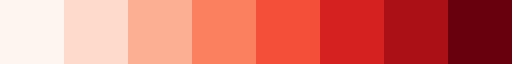

In [234]:
trial4

# break

In [40]:
# Graphing dictionaries for Urban class, and colours
if country == "GB":
    uc_dict = {1:"Urban", 4:"Rural"}
else:
    uc_dict = {1:"Urban", 2:"Urban transition", 3:"Rural transition", 4:"Rural"}

clr_dict = {1:"red", 2:"orange", 3:"blue", 4:"green"}
mort_dict = {"<60":"blue","60-120":"green", "120-180":"orange", ">180":"red"}

In [38]:
hh_only = beyondthetracks2[beyondthetracks2['Rela'].between(10,12)].copy()

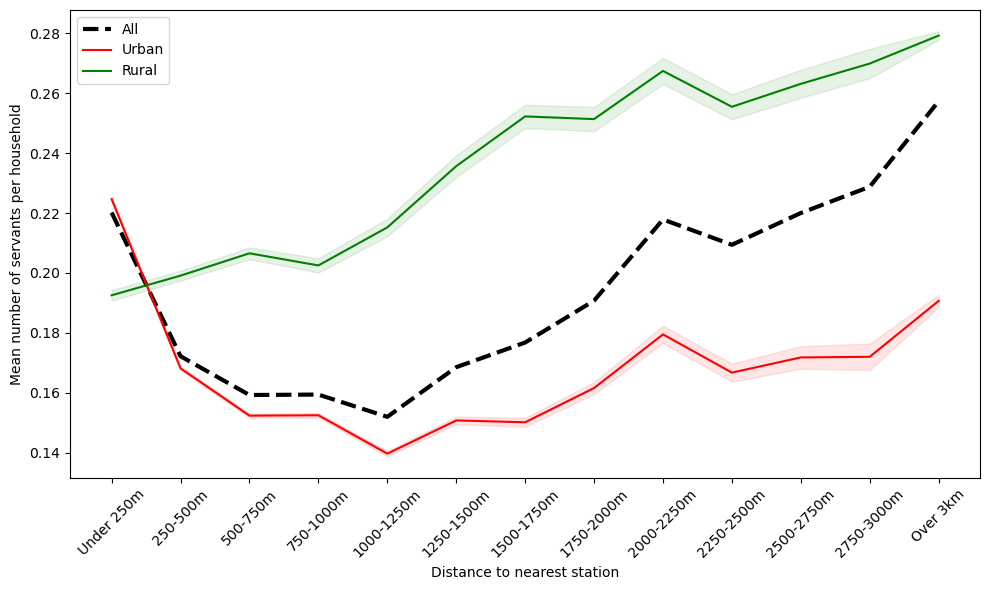

In [42]:
# Calculate averages for servants by distance to station
hh_grouped_dist = hh_only.groupby(["distance_comb_cut"]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))
hh_grouped_dist_uc = hh_only.groupby(["urban_class", "distance_comb_cut"]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))

column_to_graph = 'mean_servants'

fig, axs = plt.subplots( figsize =(10,6))
hh_grouped_g = hh_grouped_dist_uc.reset_index()


"""
For table output"""

fig_table = hh_grouped_dist_uc.unstack(0)

fig_table.columns = fig_table.columns.to_flat_index()


fig_table = pd.merge(left=hh_grouped_dist,
                 right=fig_table,
                 left_index=True,
                 right_index=True,
                 ).reset_index()

fig_table.to_csv(f"../data/outputs/tables/meanservfig_table_{country}_{year}.tsv", sep = "\t")


"""End of table output"""



one  = hh_grouped_dist_uc.unstack(0)

hh_grouped_dist.plot(ax = axs, 
                        y =[column_to_graph],
                        linewidth=3, 
                        color='black', 
                        linestyle='dashed', 
                        zorder = 0, 
                        label = ["All"], 
                        )


for uc in uc_dict.keys():


    y_label_text = 'Mean number of servants per household'
    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]
    uc_class = hh_grouped_g1.plot(ax = axs, 
                                    y = "mean_servants", 
                                    x = "distance_comb_cut", 
                                    label = uc_dict[uc], 
                                    color = clr_dict[uc], 
                                    xlabel = "Distance to nearest station",
                                    ylabel = y_label_text,
                                    rot=45 )
    plt.fill_between(hh_grouped_g1["distance_comb_cut"], 
                        hh_grouped_g1["mean_servants"] - hh_grouped_g1["sem_servants"], 
                        hh_grouped_g1["mean_servants"] + hh_grouped_g1["sem_servants"], 
                        alpha = 0.1, 
                        color = clr_dict[uc], 
                        )
plt.xticks(list(range(0, len(dist_labels))), hh_grouped_g1['distance_comb_cut'], rotation=45)
plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}.png',bbox_inches="tight", dpi = 300)
plt.tight_layout()

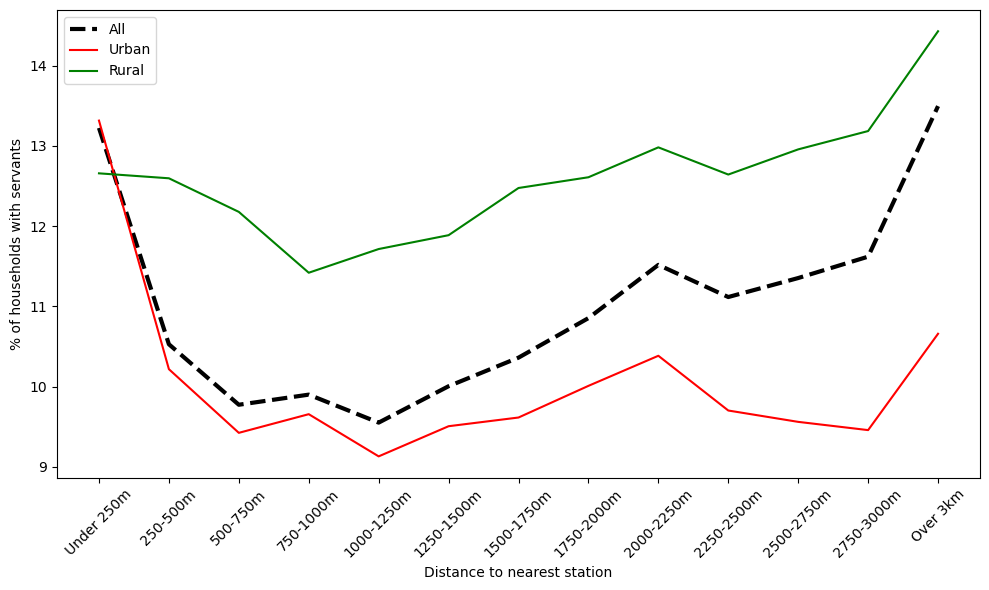

In [41]:
# Create servant binary measure
hh_only['serv_binary'] = np.where(hh_only['Servts'] > 0, 'serv', 'no_serv')

# Count number of households according to urban class, distance to station, and servant binary
serv_binary_dist_uc = hh_only.groupby(['urban_class','distance_comb_cut','serv_binary']).agg(num_hh = ('RecID','size'))

# Calculate % of households with servant or no servant
serv_binary_dist_uc['perc_hh'] = (serv_binary_dist_uc['num_hh'] / serv_binary_dist_uc.groupby(level=[0,1])['num_hh'].transform('sum') ) *100

#drop no servant binary percentage to leave only % with servants
serv_binary_dist_uc = serv_binary_dist_uc.unstack(2).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)

# Perform above calculations but grouping by distance to station only (not urban class)
serv_binary_dist = hh_only.groupby(['distance_comb_cut','serv_binary']).agg(num_hh = ('RecID','size'))
serv_binary_dist['perc_hh'] = (serv_binary_dist['num_hh'] / serv_binary_dist.groupby(level=[0])['num_hh'].transform('sum') ) *100
serv_binary_dist = serv_binary_dist.unstack(1).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)
serv_binary_dist

"""
For table output"""

fig_table = serv_binary_dist_uc.unstack(0)

fig_table.columns = fig_table.columns.to_flat_index()


fig_table = pd.merge(left=serv_binary_dist,
                 right=fig_table,
                 left_index=True,
                 right_index=True,
                 ).reset_index()

fig_table.to_csv(f"../data/outputs/tables/servbinaryfig_table_{country}_{year}.tsv", sep = "\t")


"""End of table output"""

column_to_graph = 'perc_hh'

fig, axs = plt.subplots( figsize =(10,6))
hh_grouped_g = serv_binary_dist_uc.reset_index()
serv_binary_dist.plot(ax = axs, 
                        y = [column_to_graph],
                        linewidth=3, 
                        color='black', 
                        linestyle='dashed', 
                        zorder = 0, 
                        label = ["All"], 
                        )


for uc in uc_dict.keys():


    y_label_text = '% of households with servants'
    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]
    uc_class = hh_grouped_g1.plot(ax = axs, 
                                    y = column_to_graph, 
                                    x = "distance_comb_cut", 
                                    label = uc_dict[uc], 
                                    color = clr_dict[uc], 
                                    xlabel = "Distance to nearest station",
                                    ylabel = y_label_text,
                                    rot=45 )

plt.xticks(list(range(0, len(dist_labels))), hh_grouped_g1['distance_comb_cut'], rotation=45)
plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}.png',bbox_inches="tight", dpi = 300)
plt.tight_layout()

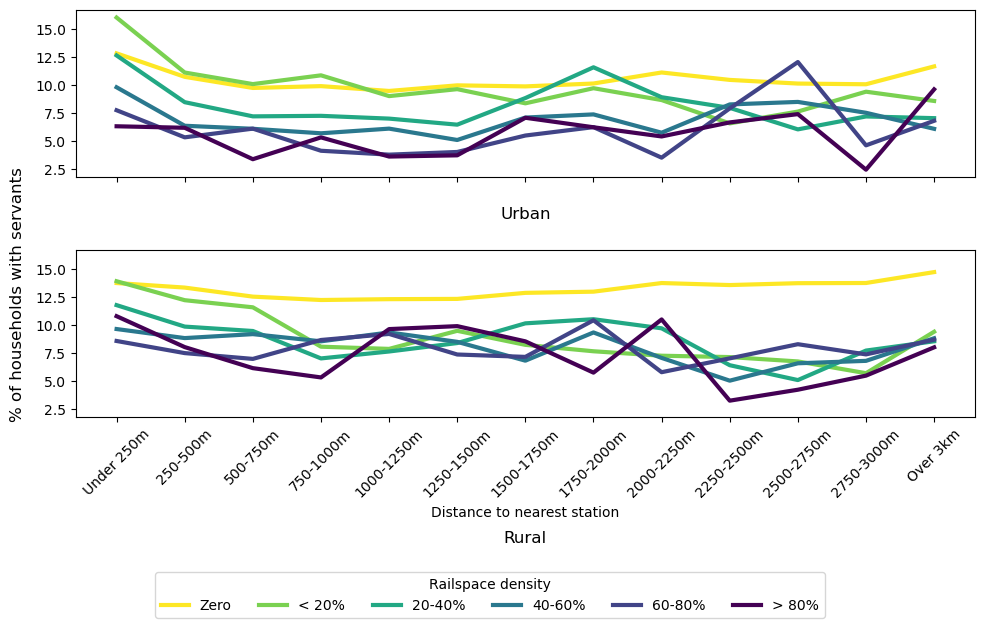

In [18]:
# this was the first try

# Create servant binary measure
hh_only['serv_binary'] = np.where(hh_only['Servts'] > 0, 'serv', 'no_serv')

# Count number of households according to urban class, distance to station, and servant binary
serv_binary_dist_uc = hh_only.groupby(['urban_class','distance_comb_cut','rail_density_100m_comb_bin','serv_binary']).agg(num_hh = ('RecID','size'))

# Calculate % of households with servant or no servant
serv_binary_dist_uc['perc_hh'] = (serv_binary_dist_uc['num_hh'] / serv_binary_dist_uc.groupby(level=[0,1,2])['num_hh'].transform('sum') ) *100



#drop no servant binary percentage to leave only % with servants
serv_binary_dist_uc = serv_binary_dist_uc.unstack(3).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)

# Perform above calculations but grouping by distance to station only (not urban class)
serv_binary_dist = hh_only.groupby(['distance_comb_cut','rail_density_100m_comb_bin','serv_binary']).agg(num_hh = ('RecID','size'))
serv_binary_dist['perc_hh'] = (serv_binary_dist['num_hh'] / serv_binary_dist.groupby(level=[0,1])['num_hh'].transform('sum') ) *100
serv_binary_dist = serv_binary_dist.unstack(2).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)
serv_binary_dist

# """
# For table output"""

# fig_table = serv_binary_dist_uc.unstack(0)

# fig_table.columns = fig_table.columns.to_flat_index()


# fig_table = pd.merge(left=serv_binary_dist,
#                  right=fig_table,
#                  left_index=True,
#                  right_index=True,
#                  ).reset_index()

# # fig_table.to_csv(f"../data/outputs/tables/servbinaryfig_table_{country}_{year}.tsv", sep = "\t")


# """End of table output"""


# ax = axs[row][col]
column_to_graph = 'perc_hh'


    # hh_grouped_dist[hh_grouped_dist["urban_class"] == uc].plot(ax = axs[row][col], 
    #                         y =column_to_graph,
    #                         x = "distance_comb_cut",
    #                         linewidth=3, 
    #                         color='black', 
    #                         linestyle='dashed', 
    #                         # zorder = 0, 
    #                         label = "_nolegend_", 
    #                         legend = False
    #                         )

fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize =(10,6), sharex=True,sharey=True)
hh_grouped_g = serv_binary_dist_uc.reset_index()
trial = serv_binary_dist.unstack(1)
to_drop = [("num_hh", x) for x  in rail_labels]
trial = trial.drop(columns = to_drop)
trial = trial.droplevel(level=0, axis=1)


trial2 = serv_binary_dist_uc.unstack(2)
to_drop = [("num_hh", x) for x  in rail_labels]
trial2.to_csv(f"../data/outputs/tables/servbinaryrailspace_distance_fig_table_{country}_{year}.tsv", sep = "\t")
trial2 = trial2.drop(columns = to_drop)
trial2 = trial2.droplevel(level=0, axis=1).reset_index()



# for rl in rail_labels:
#     print(rl)
#     trial.plot(ax = axs[0], 
#                             y = rl,
#                             linewidth=3, 
#                             linestyle='dashed', 
#                             zorder = 0, 
#                             )

trial4 = plt.colormaps["viridis_r"].resampled(6)

for enum, uc in enumerate(uc_dict.keys()):
    for enum2, rl in enumerate(rail_labels):

        if enum == 0:
            row = 0
            col = 0
            offset = -0.3
        else:
            row = 1
            col = 0
            offset = -0.8



        y_label_text = '% of households with servants'
        hh_grouped_g1 = trial2[trial2["urban_class"] == uc]
        uc_class = hh_grouped_g1.plot(ax = axs[row], 
                                        y = rl,
                                        x = "distance_comb_cut",
                                        xlabel="Distance to nearest station",
                                        rot=45,
                                        color=trial4(enum2),
                                        lw=3,
                                        legend=False)

        uc_class.set_title(uc_dict[uc], y=offset)
plt.xticks(list(range(0, len(dist_labels))), hh_grouped_g1['distance_comb_cut'], rotation=45)
# fig.legend()
fig.supylabel(y_label_text, y = 0.5)

fig.legend(labels=rail_labels,loc="lower center",ncols=6, bbox_to_anchor = (0.5,-0.05), title="Railspace density")
plt.tight_layout()
plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}_railspaceanddistance.png',bbox_inches="tight", dpi = 300)


In [26]:
serv_binary_dist_uc

num_hh    perc_hh
urban_class distance_comb_cut rail_density_100m_comb_bin                   
1.0         Under 250m        Zero                         29771  12.854546
                              < 20%                        46696  16.048886
                              20-40%                       18904  12.665657
                              40-60%                        8878   9.826558
                              60-80%                        3240   7.777804
...                                                          ...        ...
4.0         Over 3km          < 20%                          977   9.427772
                              20-40%                         587   8.576856
                              40-60%                         334   8.847682
                              60-80%                         185   8.718190
                              > 80%                           59   8.038147

[156 rows x 2 columns]

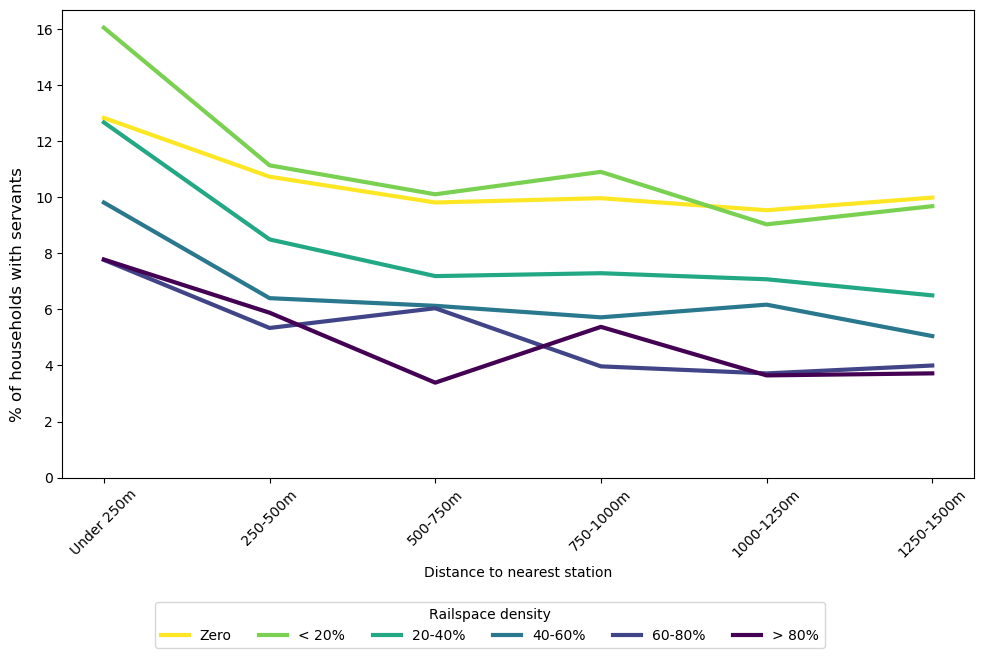

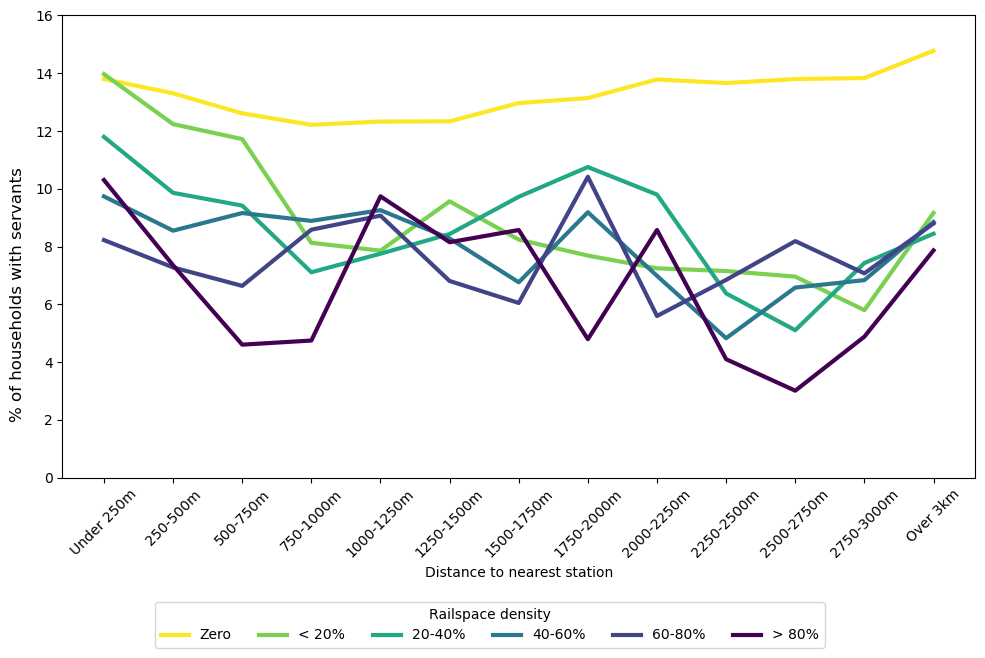

In [44]:
# second try plotting urban and rural separately


# this was the first try

# Create servant binary measure
hh_only['serv_binary'] = np.where(hh_only['Servts'] > 0, 'serv', 'no_serv')

# Count number of households according to urban class, distance to station, and servant binary
serv_binary_dist_uc = hh_only.groupby(['urban_class','distance_comb_cut','rail_density_100m_comb_bin','serv_binary']).agg(num_hh = ('RecID','size'))

# Calculate % of households with servant or no servant
serv_binary_dist_uc['perc_hh'] = (serv_binary_dist_uc['num_hh'] / serv_binary_dist_uc.groupby(level=[0,1,2])['num_hh'].transform('sum') ) *100



#drop no servant binary percentage to leave only % with servants
serv_binary_dist_uc = serv_binary_dist_uc.unstack(3).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)

# Perform above calculations but grouping by distance to station only (not urban class)
serv_binary_dist = hh_only.groupby(['distance_comb_cut','rail_density_100m_comb_bin','serv_binary']).agg(num_hh = ('RecID','size'))
serv_binary_dist['perc_hh'] = (serv_binary_dist['num_hh'] / serv_binary_dist.groupby(level=[0,1])['num_hh'].transform('sum') ) *100
serv_binary_dist = serv_binary_dist.unstack(2).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)
serv_binary_dist


# table output
trial2 = serv_binary_dist_uc.unstack(2)
to_drop = [("num_hh", x) for x  in rail_labels]
trial2.to_csv(f"../data/outputs/tables/servbinaryrailspace_distance_fig_table_{country}_{year}.tsv", sep = "\t")
trial2 = trial2.drop(columns = to_drop)
trial2 = trial2.droplevel(level=0, axis=1).reset_index()



# for rl in rail_labels:
#     print(rl)
#     trial.plot(ax = axs[0], 
#                             y = rl,
#                             linewidth=3, 
#                             linestyle='dashed', 
#                             zorder = 0, 
#                             )

dist_labels_short = ['Under 250m','250-500m','500-750m','750-1000m','1000-1250m','1250-1500m',]

trial4 = plt.colormaps["viridis_r"].resampled(6)

for enum, uc in enumerate(uc_dict.keys()):
    if uc == 1:
        distanceplotlabs = dist_labels_short
    else:
        distanceplotlabs = dist_labels
    fig, axs = plt.subplots(figsize =(10,6))

    for enum2, rl in enumerate(rail_labels):

        if enum == 0:
            row = 0
            col = 0
            offset = -0.3
        else:
            row = 1
            col = 0
            offset = -0.3


        y_label_text = '% of households with servants'
        hh_grouped_g1 = trial2[trial2["urban_class"] == uc]
        uc_class = hh_grouped_g1[hh_grouped_g1["distance_comb_cut"].isin(distanceplotlabs)].plot(ax=axs,
                                        y = rl,
                                        x = "distance_comb_cut",
                                        xlabel="Distance to nearest station",
                                        rot=45,
                                        color=trial4(enum2),
                                        lw=3,
                                        legend=False)

    # uc_class.set_title(uc_dict[uc], y=offset)
    plt.xticks(list(range(0, len(distanceplotlabs))), distanceplotlabs, rotation=45)
    plt.yticks([0, 2,4,6,8,10,12,14,16], [0, 2,4,6,8,10,12,14,16] )
    # fig.legend()
    fig.supylabel(y_label_text, y = 0.5)

    fig.legend(labels=rail_labels,loc="lower center",ncols=6, bbox_to_anchor = (0.5,-0.1), title="Railspace density")
    plt.tight_layout()
    plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}_railspaceanddistance_{uc_dict[uc]}.png',bbox_inches="tight", dpi = 300)



In [41]:
hh_grouped_g1

rail_density_100m_comb_bin,urban_class,distance_comb_cut,Zero,< 20%,20-40%,40-60%,60-80%,> 80%
13,4.0,Under 250m,13.774549,13.935301,11.802829,9.670431,8.603989,10.816777
14,4.0,250-500m,13.368754,12.243670,9.887969,8.862685,7.523045,8.059385
15,4.0,500-750m,12.562153,11.608797,9.495102,9.215579,7.005141,6.180666
16,4.0,750-1000m,12.260712,8.094107,7.048270,8.574549,8.693416,5.351171
17,4.0,1000-1250m,12.335734,7.899160,7.666555,9.365994,9.232481,9.665428
18,4.0,1250-1500m,12.359530,9.511419,8.419244,8.527755,7.397959,9.929078
19,4.0,1500-1750m,12.898155,8.259033,10.178571,6.847698,7.185629,8.571429
20,4.0,1750-2000m,13.004809,7.686424,10.546875,9.365079,10.454545,5.780347
21,4.0,2000-2250m,13.774527,7.289528,9.735509,7.094595,5.818966,10.526316
22,4.0,2250-2500m,13.594876,7.168588,6.442880,5.063291,7.053292,3.278689


In [47]:

hh_grouped_g1[rail_labels].max().max()

16.048886276854972

# end of break

## Create grouped household data

In [25]:
# Select only household heads
hh_only = beyondthetracks[beyondthetracks['Rela'].between(10,12)].copy()




In [29]:
len(hh_only)

7023434

In [18]:
hh_only = hh_only.dropna(subset=["os_open_roads_EW_1901"])
hh_only

,RecID,os_open_roads_EW_1901,distance_comb,rail_density_100m_comb,rail_density_200m_comb,ParID,NoOfRoomsCode,Size,Age,Rela,Occode,Servts,custom_occ,urban_class,distance_comb_cut,rail_density_100m_comb_bin,rail_density_200m_comb_bin
0,1,osgb4000000030483049_100001_10101,55.944810,0.375975,0.293047,1,NaN,7,63.0,11,409.0,0.0,NaN,1.0,Under 250m,20-40%,20-40%
7,8,osgb4000000030483049_100001_10101,55.944810,0.375975,0.293047,1,2.0,6,43.0,11,719.0,0.0,L,1.0,Under 250m,20-40%,20-40%
13,14,osgb4000000030483049_100001_10101,55.944810,0.375975,0.293047,1,NaN,13,33.0,11,711.0,4.0,NaN,1.0,Under 250m,20-40%,20-40%
26,27,osgb4000000030483049_100001_10101,55.944810,0.375975,0.293047,1,4.0,7,37.0,11,668.0,0.0,NaN,1.0,Under 250m,20-40%,20-40%
33,34,osgb4000000030483049_100001_10101,55.944810,0.375975,0.293047,1,1.0,2,64.0,12,NaN,0.0,NaN,1.0,Under 250m,20-40%,20-40%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32315321,32315322,osgb4000000012508801_111530_6310003,14305.081549,0.207071,0.204031,15262,NaN,4,47.0,11,124.0,0.0,CBD,1.0,Over 3km,20-40%,20-40%
32315325,32315326,osgb4000000012508801_111530_6310003,14305.081549,0.207071,0.204031,15262,NaN,3,49.0,11,158.0,0.0,NaN,1.0,Over 3km,20-40%,20-40%
32315328,32315329,osgb4000000012508801_111530_6310003,14305.081549,0.207071,0.204031,15262,NaN,9,46.0,11,429.0,0.0,RW,1.0,Over 3km,20-40%,20-40%
32315337,32315338,osgb4000000012508801_111530_6310003,14305.081549,0.207071,0.204031,15262,NaN,3,37.0,11,158.0,0.0,NaN,1.0,Over 3km,20-40%,20-40%


In [30]:
hh_only["Servts_streets"] = hh_only.groupby("comb_id")["Servts"].transform("mean")
hh_only

,RecID,os_open_roads_EW_1901,gb1900_EW_1901,distance_comb,rail_density_100m_comb,rail_density_200m_comb,comb_id,ParID,NoOfRoomsCode,Size,...,Occode,Servts,custom_occ,urban_class,InfMort,distance_comb_cut,rail_density_100m_comb_bin,rail_density_200m_comb_bin,InfMort_bin,Servts_streets
0,1,osgb4000000030483049_100001_10101,5866e8292c66dc10b8069453_100001_10101,55.94481,0.375975,0.293047,osgb4000000030483049_100001_10101,1,NaN,7,...,409.0,0.0,NaN,1.0,175.79,Under 250m,20-40%,20-40%,120-180,0.43038
7,8,osgb4000000030483049_100001_10101,5866e8292c66dc10b8069453_100001_10101,55.94481,0.375975,0.293047,osgb4000000030483049_100001_10101,1,2.0,6,...,719.0,0.0,L,1.0,175.79,Under 250m,20-40%,20-40%,120-180,0.43038
13,14,osgb4000000030483049_100001_10101,5866e8292c66dc10b8069453_100001_10101,55.94481,0.375975,0.293047,osgb4000000030483049_100001_10101,1,NaN,13,...,711.0,4.0,NaN,1.0,175.79,Under 250m,20-40%,20-40%,120-180,0.43038
26,27,osgb4000000030483049_100001_10101,5866e8292c66dc10b8069453_100001_10101,55.94481,0.375975,0.293047,osgb4000000030483049_100001_10101,1,4.0,7,...,668.0,0.0,NaN,1.0,175.79,Under 250m,20-40%,20-40%,120-180,0.43038
33,34,osgb4000000030483049_100001_10101,5866e8292c66dc10b8069453_100001_10101,55.94481,0.375975,0.293047,osgb4000000030483049_100001_10101,1,1.0,2,...,NaN,0.0,NaN,1.0,175.79,Under 250m,20-40%,20-40%,120-180,0.43038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32466213,32466214,NaN,NaN,NaN,NaN,NaN,NaN,90029,3.0,1,...,46.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32466214,32466215,NaN,NaN,NaN,NaN,NaN,NaN,90029,NaN,2,...,173.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32466216,32466217,NaN,NaN,NaN,NaN,NaN,NaN,90029,4.0,6,...,415.0,0.0,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32466222,32466223,NaN,NaN,NaN,NaN,NaN,NaN,90029,3.0,3,...,181.0,0.0,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
hh_only.to_csv("street_os_open_roads_censusvars.tsv", sep = "\t", index = False)

In [43]:
hh_only.groupby(["distance_comb_cut", "rail_density_100m_comb_bin"])['Servts'].mean().round(2).unstack(1).reset_index().to_csv("trial.tsv", sep = "\t", index = False)

#### Figure 10: Cell below calculates the mean number of servants in each household by urban class and distance to station

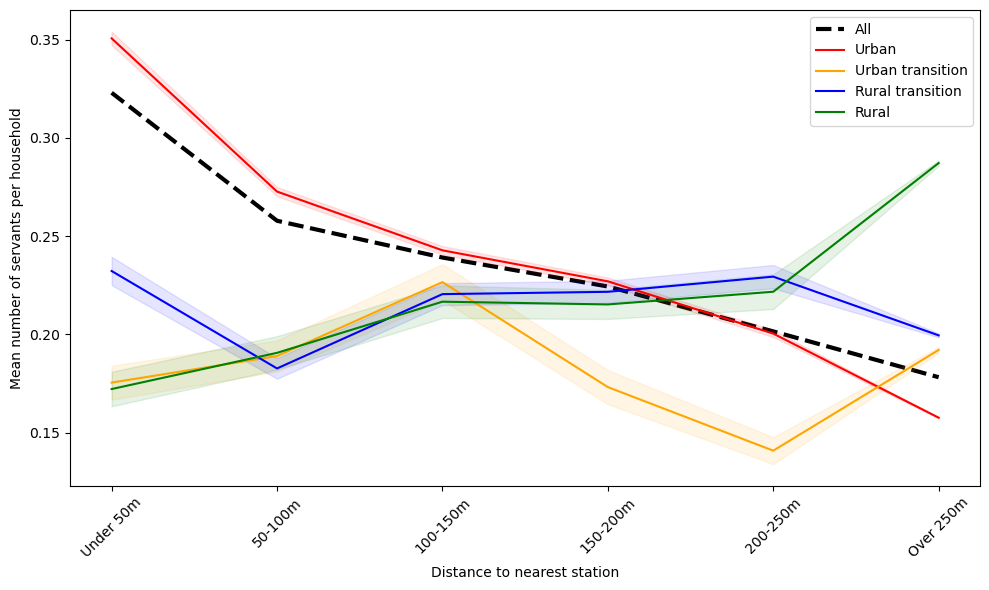

In [44]:
# Calculate averages for servants by distance to station
hh_grouped_dist = hh_only.groupby(["distance_comb_cut"]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))
hh_grouped_dist_uc = hh_only.groupby(["urban_class", "distance_comb_cut"]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))

column_to_graph = 'mean_servants'

fig, axs = plt.subplots( figsize =(10,6))
hh_grouped_g = hh_grouped_dist_uc.reset_index()

hh_grouped_dist.plot(ax = axs, 
                        y =[column_to_graph],
                        linewidth=3, 
                        color='black', 
                        linestyle='dashed', 
                        zorder = 0, 
                        label = ["All"], 
                        )


for uc in uc_dict.keys():


    y_label_text = 'Mean number of servants per household'
    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]
    uc_class = hh_grouped_g1.plot(ax = axs, 
                                    y = "mean_servants", 
                                    x = "distance_comb_cut", 
                                    label = uc_dict[uc], 
                                    color = clr_dict[uc], 
                                    xlabel = "Distance to nearest station",
                                    ylabel = y_label_text,
                                    rot=45 )
    plt.fill_between(hh_grouped_g1["distance_comb_cut"], 
                        hh_grouped_g1["mean_servants"] - hh_grouped_g1["sem_servants"], 
                        hh_grouped_g1["mean_servants"] + hh_grouped_g1["sem_servants"], 
                        alpha = 0.1, 
                        color = clr_dict[uc], 
                        )
plt.xticks(list(range(0, len(dist_labels))), hh_grouped_g1['distance_comb_cut'], rotation=45)
# plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}.png',bbox_inches="tight", dpi = 300)
plt.tight_layout()

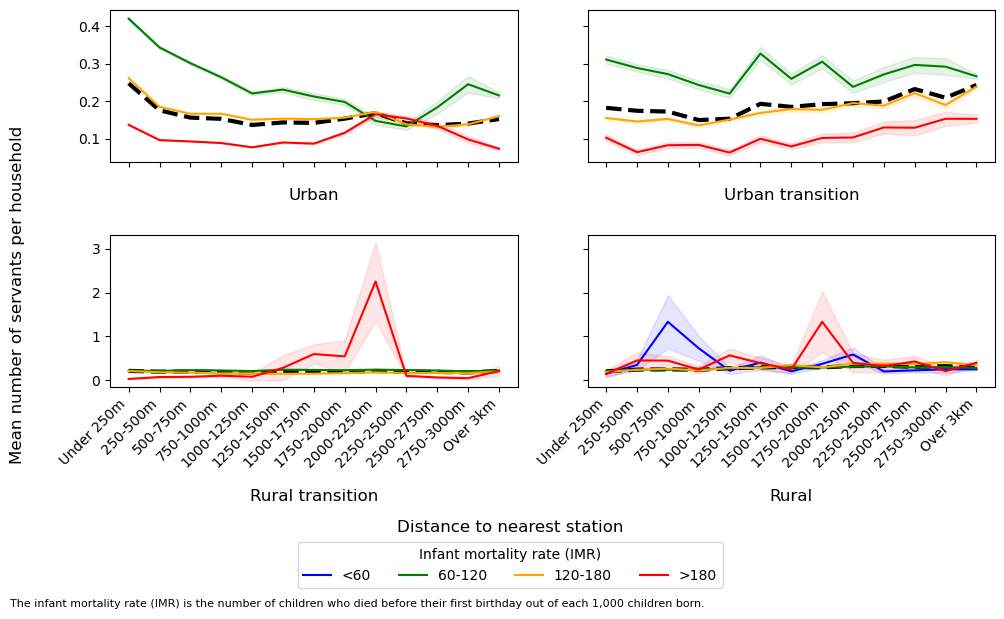

In [172]:
# Calculate averages for servants by distance to station and infant mortality
y_label_text = 'Mean number of servants per household'
x_label_text = 'Distance to nearest station'


hh_grouped_dist = hh_only.groupby(["distance_comb_cut", "urban_class", ]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))
hh_grouped_dist_uc = hh_only.groupby(["InfMort_bin","urban_class", "distance_comb_cut", ]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))

column_to_graph = 'mean_servants'

fig, axs = plt.subplots(nrows=2,ncols=2, figsize =(10,6), sharex=True, sharey="row")
hh_grouped_g = hh_grouped_dist_uc.reset_index()

hh_grouped_dist = hh_grouped_dist.reset_index()
# print(hh_grouped_dist)
col = 0
row = 0

for num, uc in enumerate(uc_dict.keys()):
    
    if num < 2:
        row = row
        col = num
        title_loc = -0.3

    else:
        row = 1
        col = num - 2
        title_loc = -0.8

    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]

    hh_grouped_dist[hh_grouped_dist["urban_class"] == uc].plot(ax = axs[row][col], 
                            y =column_to_graph,
                            x = "distance_comb_cut",
                            linewidth=3, 
                            color='black', 
                            linestyle='dashed', 
                            # zorder = 0, 
                            label = "_nolegend_", 
                            legend = False
                            )


    for lab in mort_labels:


        hh_grouped_g2 = hh_grouped_g1[hh_grouped_g1["InfMort_bin"] == lab]
        uc_class = hh_grouped_g2.plot(ax = axs[row][col], 
                                        y = "mean_servants", 
                                        x = "distance_comb_cut", 
                                        # label = mort_dict[lab], 
                                        color = mort_dict[lab], 
                                        # xlabel = "Distance to nearest station",
                                        # ylabel = y_label_text,
                                        rot=45,
                                        xticks = range(0, len(dist_labels)),
                                        legend=False)
        uc_class.set_title(uc_dict[uc], y=title_loc)

        uc_class.fill_between(hh_grouped_g2["distance_comb_cut"], 
                            hh_grouped_g2["mean_servants"] - hh_grouped_g2["sem_servants"], 
                            hh_grouped_g2["mean_servants"] + hh_grouped_g2["sem_servants"], 
                            alpha = 0.1, 
                            color = mort_dict[lab],
                            label = '_nolegend_' 
                            )
        uc_class.set(xlabel=None)
        uc_class.set_xticklabels(dist_labels, rotation=45,horizontalalignment='right')
fig.supylabel(y_label_text, x = 0)
fig.supxlabel(x_label_text, y = 0.1)
fig.legend(labels=mort_labels,loc="lower center",ncols=4, bbox_to_anchor = (0.5,0), title = "Infant mortality rate (IMR)", )
plt.figtext(0, -0.02, 'The infant mortality rate (IMR) is the number of children who died before their first birthday out of each 1,000 children born.', fontsize=8)
plt.tight_layout()
plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}_infantmortality.png',bbox_inches="tight", dpi = 300)


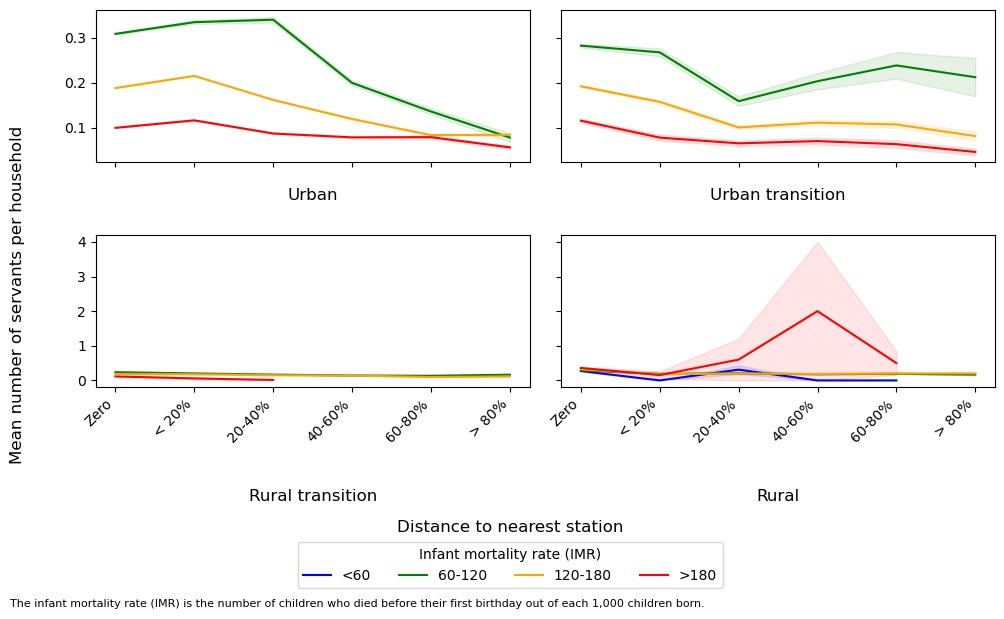

In [144]:
# Calculate averages for servants by railspace and infant mortality
y_label_text = 'Mean number of servants per household'
x_label_text = 'Distance to nearest station'

var = "rail_density_100m_comb_bin"



hh_grouped_dist = hh_only.groupby([var, "urban_class", ]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))
hh_grouped_dist_uc = hh_only.groupby(["InfMort_bin","urban_class", var, ]).agg(mean_servants = ('Servts', 'mean'), sem_servants = ("Servts","sem"))

column_to_graph = 'mean_servants'

fig, axs = plt.subplots(nrows=2,ncols=2, figsize =(10,6), sharex=True, sharey="row")
hh_grouped_g = hh_grouped_dist_uc.reset_index()

hh_grouped_dist = hh_grouped_dist.reset_index()
# print(hh_grouped_dist)
col = 0
row = 0

for num, uc in enumerate(uc_dict.keys()):
    
    if num < 2:
        row = row
        col = num
        title_loc = -0.3

    else:
        row = 1
        col = num - 2
        title_loc = -0.8

    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]



    for lab in mort_labels:


        hh_grouped_g2 = hh_grouped_g1[hh_grouped_g1["InfMort_bin"] == lab]
        uc_class = hh_grouped_g2.plot(ax = axs[row][col], 
                                        y = "mean_servants", 
                                        x = var, 
                                        # label = mort_dict[lab], 
                                        color = mort_dict[lab], 
                                        # xlabel = "Distance to nearest station",
                                        # ylabel = y_label_text,
                                        rot=45,
                                        xticks = range(0, len(rail_labels)),
                                        legend=False)
        uc_class.set_title(uc_dict[uc], y=title_loc)

        uc_class.fill_between(hh_grouped_g2[var], 
                            hh_grouped_g2["mean_servants"] - hh_grouped_g2["sem_servants"], 
                            hh_grouped_g2["mean_servants"] + hh_grouped_g2["sem_servants"], 
                            alpha = 0.1, 
                            color = mort_dict[lab],
                            label = '_nolegend_' 
                            )
        uc_class.set(xlabel=None)
        uc_class.set_xticklabels(rail_labels, rotation=45,horizontalalignment='right')
fig.supylabel(y_label_text, x = 0)
fig.supxlabel(x_label_text, y = 0.1)
fig.legend(labels=mort_labels,loc="lower center",ncols=4, bbox_to_anchor = (0.5,0), title = "Infant mortality rate (IMR)", )
plt.figtext(0, -0.02, 'The infant mortality rate (IMR) is the number of children who died before their first birthday out of each 1,000 children born.', fontsize=8)
plt.tight_layout()
# plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}_infantmortality.png',bbox_inches="tight", dpi = 300)


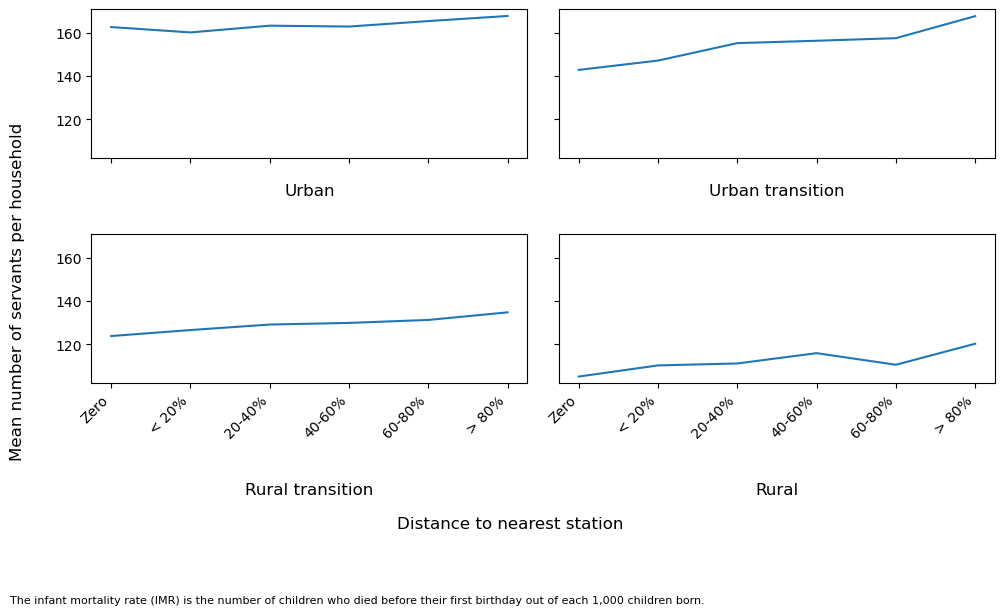

In [154]:
# Calculate averages for servants by distance to station and infant mortality
y_label_text = 'Mean number of servants per household'
x_label_text = 'Distance to nearest station'


hh_grouped_dist = beyondthetracks.groupby(["rail_density_100m_comb_bin", "urban_class", ]).agg(mean_infmort=('InfMort','mean'))
# hh_grouped_dist_uc = beyondthetracks.groupby(["InfMort_bin","urban_class", "distance_comb_cut", ]).agg(size=('RecID','size'))



fig, axs = plt.subplots(nrows=2,ncols=2, figsize =(10,6), sharex=True, sharey=True)
hh_grouped_g = hh_grouped_dist.reset_index()

col = 0
row = 0

for num, uc in enumerate(uc_dict.keys()):
    
    if num < 2:
        row = row
        col = num
        title_loc = -0.3

    else:
        row = 1
        col = num - 2
        title_loc = -0.8

    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]


    uc_class = hh_grouped_g1.plot(ax = axs[row][col], 
                                    y = "mean_infmort", 
                                    x = "rail_density_100m_comb_bin", 
                                    # label = mort_dict[lab], 
                                    # color = mort_dict[lab], 
                                    # xlabel = "Distance to nearest station",
                                    # ylabel = y_label_text,
                                    rot=45,
                                    xticks = range(0, len(rail_labels)),
                                    legend=False)
    uc_class.set_title(uc_dict[uc], y=title_loc)

        # uc_class.fill_between(hh_grouped_g2["distance_comb_cut"], 
        #                     hh_grouped_g2["mean_servants"] - hh_grouped_g2["sem_servants"], 
        #                     hh_grouped_g2["mean_servants"] + hh_grouped_g2["sem_servants"], 
        #                     alpha = 0.1, 
        #                     color = mort_dict[lab],
        #                     label = '_nolegend_' 
        #                     )
    uc_class.set(xlabel=None)
    uc_class.set_xticklabels(rail_labels, rotation=45,horizontalalignment='right')
fig.supylabel(y_label_text, x = 0)
fig.supxlabel(x_label_text, y = 0.1)
# fig.legend(labels=mort_labels,loc="lower center",ncols=4, bbox_to_anchor = (0.5,0), title = "Infant mortality rate (IMR)", )
plt.figtext(0, -0.02, 'The infant mortality rate (IMR) is the number of children who died before their first birthday out of each 1,000 children born.', fontsize=8)
plt.tight_layout()
# plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}_infantmortality.png',bbox_inches="tight", dpi = 300)


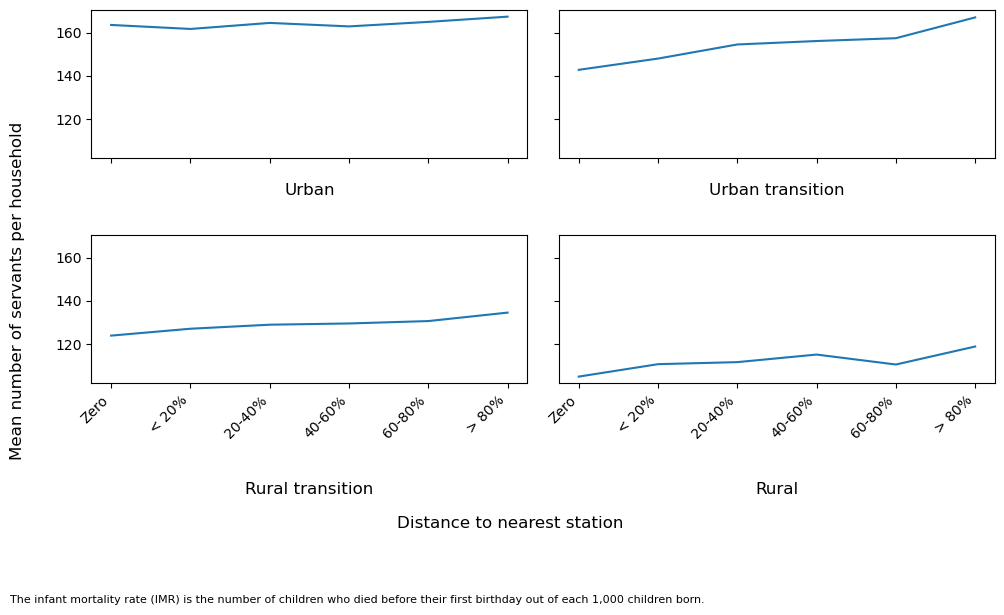

In [34]:
# Calculate averages for servants by distance to station and infant mortality
y_label_text = 'Mean number of servants per household'
x_label_text = 'Distance to nearest station'

lowclass = hh_only[hh_only["Servts_streets"] < 0.5]

hh_grouped_dist = lowclass.groupby(["rail_density_100m_comb_bin", "urban_class", ]).agg(mean_infmort=('InfMort','mean'))
# hh_grouped_dist_uc = beyondthetracks.groupby(["InfMort_bin","urban_class", "distance_comb_cut", ]).agg(size=('RecID','size'))



fig, axs = plt.subplots(nrows=2,ncols=2, figsize =(10,6), sharex=True, sharey=True)
hh_grouped_g = hh_grouped_dist.reset_index()

col = 0
row = 0

for num, uc in enumerate(uc_dict.keys()):
    
    if num < 2:
        row = row
        col = num
        title_loc = -0.3

    else:
        row = 1
        col = num - 2
        title_loc = -0.8

    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]


    uc_class = hh_grouped_g1.plot(ax = axs[row][col], 
                                    y = "mean_infmort", 
                                    x = "rail_density_100m_comb_bin", 
                                    # label = mort_dict[lab], 
                                    # color = mort_dict[lab], 
                                    # xlabel = "Distance to nearest station",
                                    # ylabel = y_label_text,
                                    rot=45,
                                    xticks = range(0, len(rail_labels)),
                                    legend=False)
    uc_class.set_title(uc_dict[uc], y=title_loc)

        # uc_class.fill_between(hh_grouped_g2["distance_comb_cut"], 
        #                     hh_grouped_g2["mean_servants"] - hh_grouped_g2["sem_servants"], 
        #                     hh_grouped_g2["mean_servants"] + hh_grouped_g2["sem_servants"], 
        #                     alpha = 0.1, 
        #                     color = mort_dict[lab],
        #                     label = '_nolegend_' 
        #                     )
    uc_class.set(xlabel=None)
    uc_class.set_xticklabels(rail_labels, rotation=45,horizontalalignment='right')
fig.supylabel(y_label_text, x = 0)
fig.supxlabel(x_label_text, y = 0.1)
# fig.legend(labels=mort_labels,loc="lower center",ncols=4, bbox_to_anchor = (0.5,0), title = "Infant mortality rate (IMR)", )
plt.figtext(0, -0.02, 'The infant mortality rate (IMR) is the number of children who died before their first birthday out of each 1,000 children born.', fontsize=8)
plt.tight_layout()
# plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}_infantmortality.png',bbox_inches="tight", dpi = 300)


#### Figure 11: Percentage of households with live-in servants by distance to station and parish type (1901).

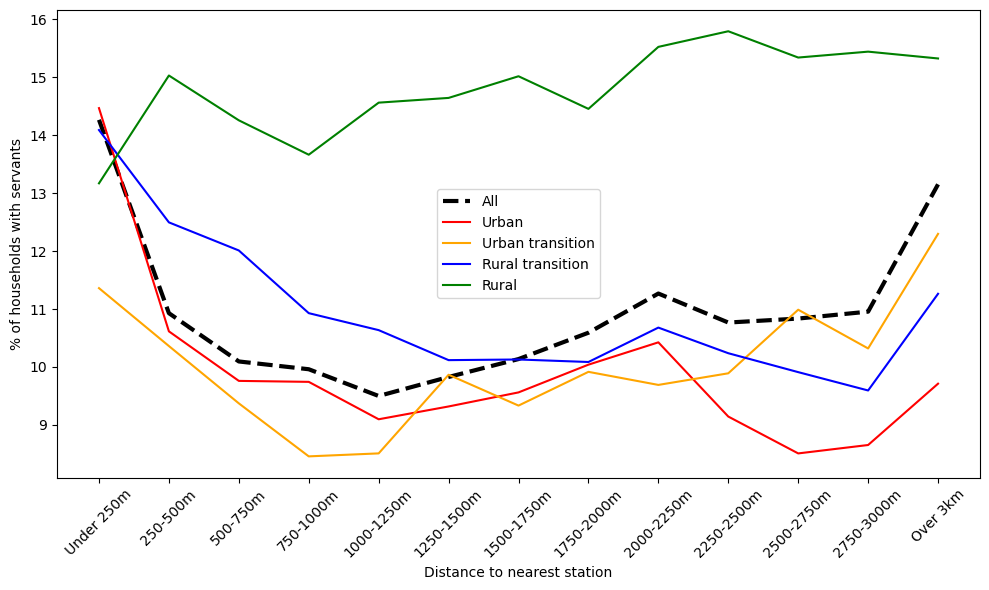

In [56]:
# Create servant binary measure
hh_only['serv_binary'] = np.where(hh_only['Servts'] > 0, 'serv', 'no_serv')

# Count number of households according to urban class, distance to station, and servant binary
serv_binary_dist_uc = hh_only.groupby(['urban_class','distance_comb_cut','serv_binary']).agg(num_hh = ('RecID','size'))

# Calculate % of households with servant or no servant
serv_binary_dist_uc['perc_hh'] = (serv_binary_dist_uc['num_hh'] / serv_binary_dist_uc.groupby(level=[0,1])['num_hh'].transform('sum') ) *100

#drop no servant binary percentage to leave only % with servants
serv_binary_dist_uc = serv_binary_dist_uc.unstack(2).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)

# Perform above calculations but grouping by distance to station only (not urban class)
serv_binary_dist = hh_only.groupby(['distance_comb_cut','serv_binary']).agg(num_hh = ('RecID','size'))
serv_binary_dist['perc_hh'] = (serv_binary_dist['num_hh'] / serv_binary_dist.groupby(level=[0])['num_hh'].transform('sum') ) *100
serv_binary_dist = serv_binary_dist.unstack(1).drop('no_serv',level=1,axis=1).droplevel(1,axis=1)
serv_binary_dist


column_to_graph = 'perc_hh'

fig, axs = plt.subplots( figsize =(10,6))
hh_grouped_g = serv_binary_dist_uc.reset_index()
serv_binary_dist.plot(ax = axs, 
                        y = [column_to_graph],
                        linewidth=3, 
                        color='black', 
                        linestyle='dashed', 
                        zorder = 0, 
                        label = ["All"], 
                        )


for uc in uc_dict.keys():


    y_label_text = '% of households with servants'
    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]
    uc_class = hh_grouped_g1.plot(ax = axs, 
                                    y = column_to_graph, 
                                    x = "distance_comb_cut", 
                                    label = uc_dict[uc], 
                                    color = clr_dict[uc], 
                                    xlabel = "Distance to nearest station",
                                    ylabel = y_label_text,
                                    rot=45 )

plt.xticks(list(range(0, len(dist_labels))), hh_grouped_g1['distance_comb_cut'], rotation=45)
plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}.png',bbox_inches="tight", dpi = 300)
plt.tight_layout()

In [30]:
hh_only.groupby(["urban_class", "typology"])["Servts"].mean().round(2).unstack(0)

urban_class,1.0,2.0,3.0,4.0
typology,,,,
amenitytradeoff,0.09,0.13,0.13,0.19
highamenity,0.22,0.20,0.22,0.24
lowamenity,0.09,0.09,0.09,0.21
notnearrail,0.15,0.23,0.21,0.30
other,0.14,0.17,0.19,0.24


In [31]:
hh_only.groupby(["urban_class"])["Servts"].mean().round(2)

urban_class
1.0    0.16
2.0    0.19
3.0    0.20
4.0    0.26
Name: Servts, dtype: float64

#### Figure 12: Mean number of people per room by distance to station and parish type (1901).

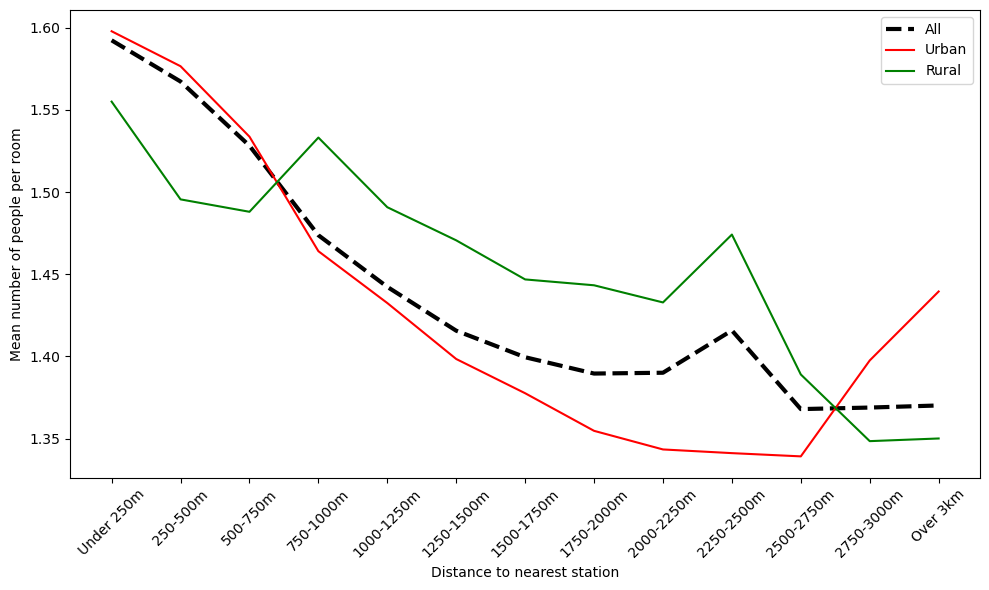

In [89]:
# Calculate average number of people per room by distance to station
hh_only['room_size'] = np.where(hh_only['NoOfRoomsCode'].between(0,997), hh_only['Size']/hh_only['NoOfRoomsCode'], np.nan)
hh_only["room_size"] = np.where(hh_only["room_size"] == np.inf, np.nan, hh_only["room_size"])
hh_grouped_dist_uc = hh_only.groupby(['distance_comb_cut', 'urban_class']).agg(room_size = ('room_size', 'mean'), sem_roomsize = ("room_size","sem"))
hh_grouped_dist = hh_only.groupby(['distance_comb_cut']).agg(room_size = ('room_size', 'mean'))


column_to_graph = 'room_size'

fig, axs = plt.subplots( figsize =(10,6))
hh_grouped_g = hh_grouped_dist_uc.reset_index()

hh_grouped_dist.plot(ax = axs, 
                        y =[column_to_graph],
                        linewidth=3, 
                        color='black', 
                        linestyle='dashed', 
                        zorder = 0, 
                        label = ["All"], 
                        )


for uc in uc_dict.keys():


    y_label_text = 'Mean number of people per room'
    hh_grouped_g1 = hh_grouped_g[hh_grouped_g["urban_class"] == uc]
    uc_class = hh_grouped_g1.plot(ax = axs, 
                                    y = column_to_graph, 
                                    x = "distance_comb_cut", 
                                    label = uc_dict[uc], 
                                    color = clr_dict[uc], 
                                    xlabel = "Distance to nearest station",
                                    ylabel = y_label_text,
                                    rot=45 )
    # plt.fill_between(hh_grouped_g1["distance_comb_cut"], 
    #                     hh_grouped_g1[column_to_graph] - hh_grouped_g1["sem_roomsize"], 
    #                     hh_grouped_g1[column_to_graph] + hh_grouped_g1["sem_roomsize"], 
    #                     alpha = 0.1, 
    #                     color = clr_dict[uc], 
    #                     )
plt.xticks(list(range(0, len(dist_labels))), hh_grouped_g1['distance_comb_cut'], rotation=45)
plt.savefig(f'../data/outputs/graphs/{year}_{country}_{column_to_graph}.png',bbox_inches="tight", dpi = 300)
plt.tight_layout()

In [16]:
age_occ_filter = beyondthetracks[(beyondthetracks["Age"] >= 16) & 
                                    (beyondthetracks["Occode"].isna() == False)]

grouped_dist = age_occ_filter.groupby(["urban_class", "custom_occ"], dropna = False).agg(num = ("RecID", "size"))
grouped_dist['perc'] = ((grouped_dist['num'] / grouped_dist.groupby(level=[0])['num'].transform('sum') ) *100).round(2)
testing = grouped_dist.unstack(1).drop(columns = ["num"]).dropna(axis=1).droplevel(0, axis=1).reset_index()

In [17]:
testing = grouped_dist.unstack(1).drop(columns=["num"]).droplevel(0,axis=1).reset_index().drop(columns=["other"]).drop(labels=2)
testing

custom_occ,urban_class,CBD,D,L,M,RW,T
0,1.0,5.24,1.74,18.81,6.63,3.27,0.68
1,4.0,2.07,0.41,33.26,7.05,2.24,0.20


In [18]:
occs = ["CBD", "D", "L", "M", "RW", "T", ]
for occ in occs:
    occ_dict_new = dict(zip(testing["urban_class"], testing[occ]))
    print(occ_dict_new)
    beyondthetracks[f"{occ}_baseline"] = beyondthetracks["urban_class"].map(occ_dict_new)


{1.0: 5.24, 4.0: 2.07}
{1.0: 1.74, 4.0: 0.41}
{1.0: 18.81, 4.0: 33.26}
{1.0: 6.63, 4.0: 7.05}
{1.0: 3.27, 4.0: 2.24}
{1.0: 0.68, 4.0: 0.2}


In [24]:
beyondthetracks

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32493318 entries, 0 to 32493317
Data columns (total 27 columns):
 #   Column                      Dtype   
---  ------                      -----   
 0   RecID                       int64   
 1   os_open_roads_EW_1901       object  
 2   gb1900_EW_1901              object  
 3   distance_comb               float64 
 4   rail_density_100m_comb      float64 
 5   rail_density_200m_comb      float64 
 6   comb_id                     object  
 7   ParID                       int64   
 8   NoOfRoomsCode               float64 
 9   Size                        int64   
 10  Age                         float64 
 11  Rela                        int64   
 12  Occode                      float64 
 13  Servts                      float64 
 14  custom_occ                  object  
 15  urban_class                 float64 
 16  InfMort                     float64 
 17  distance_comb_cut           category
 18  rail_density_100m_comb_bin  category
 19

In [20]:
grouped_dist = age_occ_filter.groupby(["comb_id","custom_occ"],).agg(num = ("RecID", "size"))
grouped_dist['perc'] = ((grouped_dist['num'] / grouped_dist.groupby(level=[0])['num'].transform('sum') ) *100).round(2)
grouped_dist

num    perc
comb_id                                 custom_occ             
52643d573f71630002000006_111483_6290001 L             1   50.00
                                        other         1   50.00
52643d753f7163000200000a_111483_6290001 other         2  100.00
52643d94db2eed0002000008_111483_6290001 L             1   33.33
                                        other         2   66.67
...                                                 ...     ...
osgb5000005275941557_101382_1450001     L             2   40.00
                                        RW            1   20.00
                                        other         2   40.00
osgb5000005276015361_100003_240006      CBD           2   66.67
                                        other         1   33.33

[813978 rows x 2 columns]

In [23]:
test = grouped_dist.unstack(1).drop(columns=["num"]).droplevel(0, axis=1).reset_index().drop(columns=["other"])
test

custom_occ,comb_id,CBD,D,L,M,RW,T
0,52643d573f71630002000006_111483_6290001,NaN,NaN,50.00,NaN,NaN,NaN
1,52643d753f7163000200000a_111483_6290001,NaN,NaN,NaN,NaN,NaN,NaN
2,52643d94db2eed0002000008_111483_6290001,NaN,NaN,33.33,NaN,NaN,NaN
3,52643e4d2807ba000200001b_111477_6290001,NaN,NaN,50.00,NaN,NaN,NaN
4,526638d0de51c70002000034_111024_6050004,NaN,NaN,50.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...
294954,osgb5000005275823288_109116_5240003,NaN,NaN,44.44,NaN,NaN,NaN
294955,osgb5000005275841203_105676_3630001,NaN,4.55,12.88,11.36,1.52,NaN
294956,osgb5000005275853513_110977_6020003,22.22,NaN,NaN,NaN,NaN,NaN
294957,osgb5000005275941557_101382_1450001,NaN,NaN,40.00,NaN,20.00,NaN


In [31]:
test2 = pd.merge

custom_occ,comb_id,CBD,D,L,M,RW,T,NaN
0,52643d573f71630002000006_111483_6290001,NaN,NaN,50.00,NaN,NaN,NaN,50.00
1,52643d753f7163000200000a_111483_6290001,NaN,NaN,NaN,NaN,NaN,NaN,100.00
2,52643d94db2eed0002000008_111483_6290001,NaN,NaN,33.33,NaN,NaN,NaN,66.67
3,52643e4d2807ba000200001b_111477_6290001,NaN,NaN,50.00,NaN,NaN,NaN,50.00
4,526638d0de51c70002000034_111024_6050004,NaN,NaN,50.00,NaN,NaN,NaN,50.00
...,...,...,...,...,...,...,...,...
294955,osgb5000005275841203_105676_3630001,NaN,4.55,12.88,11.36,1.52,NaN,69.70
294956,osgb5000005275853513_110977_6020003,22.22,NaN,NaN,NaN,NaN,NaN,77.78
294957,osgb5000005275941557_101382_1450001,NaN,NaN,40.00,NaN,20.00,NaN,40.00
294958,osgb5000005276015361_100003_240006,66.67,NaN,NaN,NaN,NaN,NaN,33.33


In [40]:
age_occ_filter = beyondthetracks[(beyondthetracks["Age"] >= 16) & 
                                    (beyondthetracks["Occode"].isna() == False)]

grouped_dist = age_occ_filter.groupby(["typology", "urban_class", "custom_occ"], dropna = False).agg(num = ("RecID", "size"))
grouped_dist['perc'] = ((grouped_dist['num'] / grouped_dist.groupby(level=[0,1])['num'].transform('sum') ) *100).round(2)
grouped_dist

num   perc
typology urban_class custom_occ              
far_high 1.0         CBD           535   2.58
                     D             363   1.75
                     L            2461  11.86
                     M            6265  30.19
                     RW           1493   7.20
...                                ...    ...
other    NaN         L           17514    NaN
                     M            2556    NaN
                     RW            809    NaN
                     T             148    NaN
                     NaN         72599    NaN

[147 rows x 2 columns]

In [41]:
grouped_dist.unstack(1)

num                                          perc  \
urban_class                 1.0       2.0       3.0       4.0      NaN    1.0   
typology  custom_occ                                                            
far_high  CBD             535.0      57.0     124.0      43.0      NaN   2.58   
          D               363.0      32.0      28.0       4.0      NaN   1.75   
          L              2461.0     665.0     906.0     727.0      NaN  11.86   
          M              6265.0    1763.0    1977.0     352.0      NaN  30.19   
          RW             1493.0     209.0     310.0     166.0      NaN   7.20   
          T                62.0       7.0      13.0       3.0      NaN   0.30   
          NaN            9570.0    1737.0    2857.0    1270.0      NaN  46.12   
far_low   CBD           32338.0    3956.0    8010.0    6446.0      NaN   4.85   
          D              7564.0    1084.0    1914.0     922.0      NaN   1.13   
          L            118473.0   70956.0  134558.0  252513.0      NaN  17.76   
          M             58107.0   33393.0   48769.0   12834.0      NaN   8.71   
          RW            21720.0    3975.0    7224.0    5087.0      NaN   3.26   
          T              4486.0     307.0     689.0     541.0      NaN   0.67   
          NaN          424284.0  116619.0  234944.0  302923.0      NaN  63.61   
near_high CBD            6980.0     220.0     395.0     116.0      NaN   4.77   
          D              4446.0     142.0     102.0      25.0      NaN   3.04   
          L             23586.0    1304.0    1846.0    1066.0      NaN  16.11   
          M             11360.0    2522.0    2003.0     231.0      NaN   7.76   
          RW             7700.0     511.0     838.0     558.0      NaN   5.26   
          T               974.0      28.0      46.0       8.0      NaN   0.67   
          NaN           91328.0    4196.0    6085.0    2285.0      NaN  62.39   
near_low  CBD          171983.0    3138.0    9470.0    3750.0      NaN   6.86   
          D             44183.0     858.0    1625.0     491.0      NaN   1.76   
          L            468029.0   17079.0   52485.0   32289.0      NaN  18.68   
          M            102846.0   10193.0   15716.0    2772.0      NaN   4.10   
          RW            76476.0    3118.0    8693.0    3745.0      NaN   3.05   
          T             21095.0     287.0    1050.0     338.0      NaN   0.84   
          NaN         1620844.0   44566.0  148226.0   69013.0      NaN  64.69   
other     CBD          342241.0   13735.0   27984.0   13651.0   2290.0   5.06   
          D            127942.0    4476.0    6529.0    2376.0    314.0   1.89   
          L           1226891.0  136839.0  283687.0  364585.0  17514.0  18.14   
          M            398723.0  103500.0  121966.0   31905.0   2556.0   5.90   
          RW           228529.0   15650.0   30332.0   18829.0    809.0   3.38   
          T             45827.0    1159.0    2820.0    1339.0    148.0   0.68   
          NaN         4391656.0  287597.0  591141.0  492871.0  72599.0  64.95   

                                               
urban_class             2.0    3.0    4.0 NaN  
typology  custom_occ                           
far_high  CBD          1.28   2.00   1.68 NaN  
          D            0.72   0.45   0.16 NaN  
          L           14.88  14.58  28.34 NaN  
          M           39.44  31.81  13.72 NaN  
          RW           4.68   4.99   6.47 NaN  
          T            0.16   0.21   0.12 NaN  
          NaN         38.86  45.97  49.51 NaN  
far_low   CBD          1.72   1.84   1.11 NaN  
          D            0.47   0.44   0.16 NaN  
          L           30.81  30.85  43.44 NaN  
          M           14.50  11.18   2.21 NaN  
          RW           1.73   1.66   0.88 NaN  
          T            0.13   0.16   0.09 NaN  
          NaN         50.64  53.87  52.11 NaN  
near_high CBD          2.47   3.49   2.70 NaN  
          D            1.59   0.90   0.58 NaN  
          L           14.61  16.31  2

#### Figure 13-16: Percentage of occupied workers in different customised occupational clusters by distance from nearest station and railspace, 1901

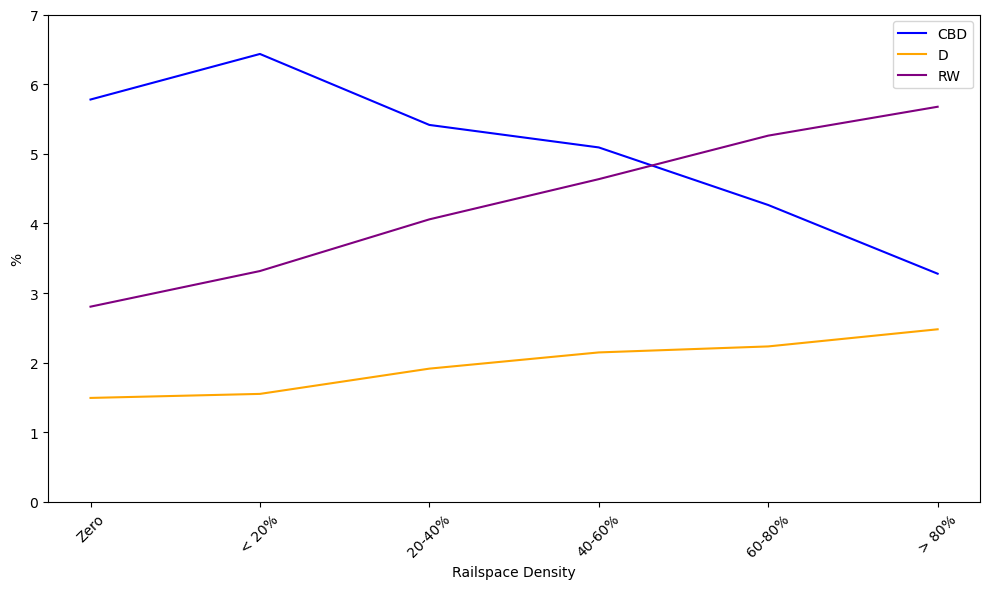

In [82]:
# Analyse % of custom occupation workers by distance to station or railspace density

analysis_type = "railspace" #distance_to_station #railspace
# analysis_type = "distance_to_station"
railspace_dist = 100
num_custom_occs = "selectoccs" #selectoccs #all_occs

if analysis_type == "railspace":

    groupby_col = f"rail_density_{railspace_dist}m_comb_bin"
    xticks_labels = rail_labels
    xlabel = "Railspace Density"
elif analysis_type == "distance_to_station":
    groupby_col = "distance_comb_cut"
    xticks_labels = dist_labels
    xlabel = "Distance to Station"

age_min = 16


applyfilter = "filter"

if applyfilter == "filter":

    age_occ_filter = beyondthetracks2[(beyondthetracks2["Age"] >= age_min) & 
                                        (beyondthetracks2["Occode"].isna() == False)
                                        & (beyondthetracks2["urban_class"] == 1) 
                                        & (beyondthetracks2["distance_comb"] < 2000)]


    grouped_dist = age_occ_filter.groupby([groupby_col, "custom_occ"], dropna = False).agg(num = ("RecID", "size"))

elif applyfilter == "nofilter":
    grouped_dist = beyondthetracks2.groupby([groupby_col, "custom_occ"], dropna = False).agg(num = ("RecID", "size"))

else:
    raise ValueError("Enter 'filter' or 'nofilter'")


grouped_dist['perc'] = (grouped_dist['num'] / grouped_dist.groupby(level=groupby_col)['num'].transform('sum') ) *100

column_to_graph = 'perc'

fig, axs = plt.subplots( figsize =(10,6))

# grouped_dist.unstack(0).to_csv(f"../data/outputs/tables/occs_perc_{analysis_type}_{country}_{year}.tsv", sep ="\t")

grouped_dist = grouped_dist.reset_index()

if num_custom_occs == "all_occs":

    cust_occ_clrs = {"CBD":"blue", "D":"orange", "L":"green", "M":"red", "RW":"purple", "T":"brown"}

elif num_custom_occs == "selectoccs":
    # cust_occ_clrs = {"CBD":"blue", "D":"orange", "RW":"purple", "M":"red"}
    cust_occ_clrs = {"CBD":"blue", "D":"orange", "RW":"purple"}

else:
    raise ValueError("Enter either 'all_occs' or 'selectoccs'")

for cust_occ in cust_occ_clrs.keys():

    y_label_text = '%'
    grouped_dist1 = grouped_dist[grouped_dist["custom_occ"] == cust_occ]
    uc_class = grouped_dist1.plot(ax = axs, 
                                    y = column_to_graph, 
                                    x = groupby_col, 
                                    label = cust_occ, 
                                    color = cust_occ_clrs[cust_occ], 
                                    xlabel = xlabel,
                                    ylabel = y_label_text,
                                    rot=45 )

plt.yticks(list(range(0, 8)), [0,1,2,3,4,5,6,7])
plt.xticks(list(range(0, len(xticks_labels))), grouped_dist1[groupby_col], rotation=45)
plt.tight_layout()
plt.savefig(f'../data/outputs/graphs/{year}_{country}_custom_occ_by_{analysis_type}_{column_to_graph}_{applyfilter}_{num_custom_occs}_urbanonlysub2km_nomanuf.png',bbox_inches="tight", dpi = 300)
# 

In [21]:
grouped_dist.unstack

,distance_comb_cut,custom_occ,num,perc
0,Under 250m,CBD,122756,6.603616
1,Under 250m,D,30847,1.659403
2,Under 250m,L,315333,16.963228
3,Under 250m,M,83422,4.487657
4,Under 250m,RW,59290,3.189485
...,...,...,...,...
86,Over 3km,L,64865,23.696795
87,Over 3km,M,34837,12.726821
88,Over 3km,RW,8143,2.974840
89,Over 3km,T,736,0.268879
